In [10]:
PROYECTO = "/home/sagemaker-user/TFM-cloud-soliutions-to-public-data/code/files"

%cd {PROYECTO}
!python -m pip install geopandas --quiet
!aws s3 sync s3://tfm-ucm-datos-publicos/data/silver/ {PROYECTO}/data/silver/
!aws s3 sync s3://tfm-ucm-datos-publicos/data/bronze/distritos/ {PROYECTO}/data/bronze/distritos/

/home/sagemaker-user/TFM-cloud-soliutions-to-public-data/code/files


In [11]:
!python 03_analisis_isla_calor.py

# ejecucion 2026-08-26 19:12 | MODO_REPLICA=False | MIN_DIAS_ANIO=300
== Isla de calor 2019 (extension) ==
    [info] 19 estaciones con <300 dias de datos, se excluyen
  [OK] meteo_todas_magnitudes: 7 estaciones, k=4, inercia=16.4, silhouette=0.097
    [info] 5 estaciones con <300 dias de datos, se excluyen
  [OK] meteo_temp_humedad: 21 estaciones, k=5, inercia=3.7, silhouette=0.510
    [info] 3 estaciones con <300 dias de datos, se excluyen
  [OK] meteo_temp_arbolado: 16 estaciones, k=4, inercia=5.4, silhouette=0.458
  [OK] contaminacion_no2: 24 estaciones, k=5, inercia=0.7, silhouette=0.601
    [info] 17 estaciones con <300 dias de datos, se excluyen
  [OK] contaminacion_no2_pm: 7 estaciones, k=4, inercia=0.9, silhouette=0.377
  [OK] correlaciones: 2 pares
  [OK] arbolado vs temperatura: 14 distritos, r=-0.462
== Isla de calor 2020 (extension) ==
    [info] 20 estaciones con <300 dias de datos, se excluyen
  [OK] meteo_todas_magnitudes: 6 estaciones, k=4, inercia=7.6, silhouette=0.12

In [12]:
import pandas as pd
base = f"{PROYECTO}/resultados/isla_calor/propio"
display(pd.read_csv(f"{base}/resumen_silhouette.csv", index_col=0).round(3))
display(pd.read_csv(f"{base}/resumen_arbolado.csv", index_col=0))

,contaminacion_no2,contaminacion_no2_pm,meteo_temp_arbolado,meteo_temp_humedad,meteo_todas_magnitudes
anio,,,,,
2019,0.601,0.377,0.458,0.510,0.097
2020,0.522,0.356,0.470,0.444,0.122
2021,0.554,0.309,0.438,0.660,0.078
2022,0.508,0.262,0.460,0.397,NaN
2023,0.682,0.254,0.531,0.505,0.014
2024,0.566,0.286,0.569,0.502,0.293
2025,0.522,0.376,0.577,0.470,0.269


,r_arbolado,n_distritos
anio,,
2019,-0.462,14
2020,-0.392,12
2021,-0.416,13
2022,-0.471,9
2023,-0.264,15
2024,-0.285,14
2025,-0.315,15


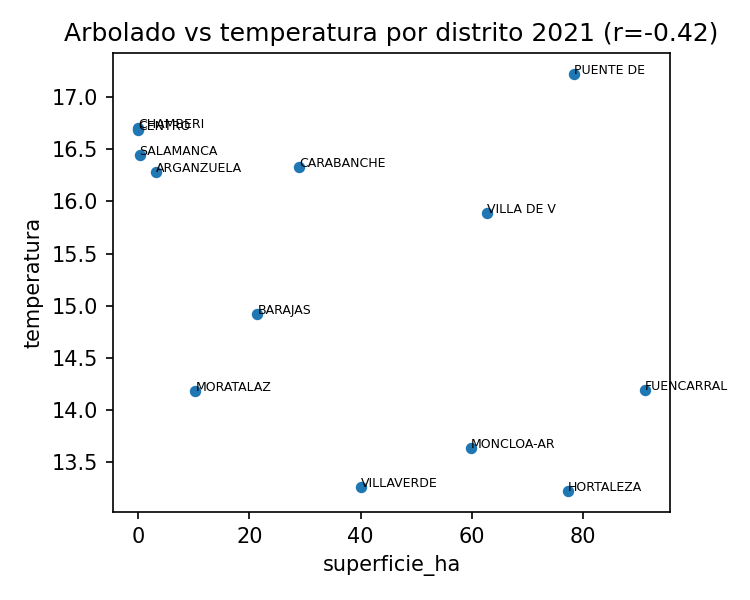

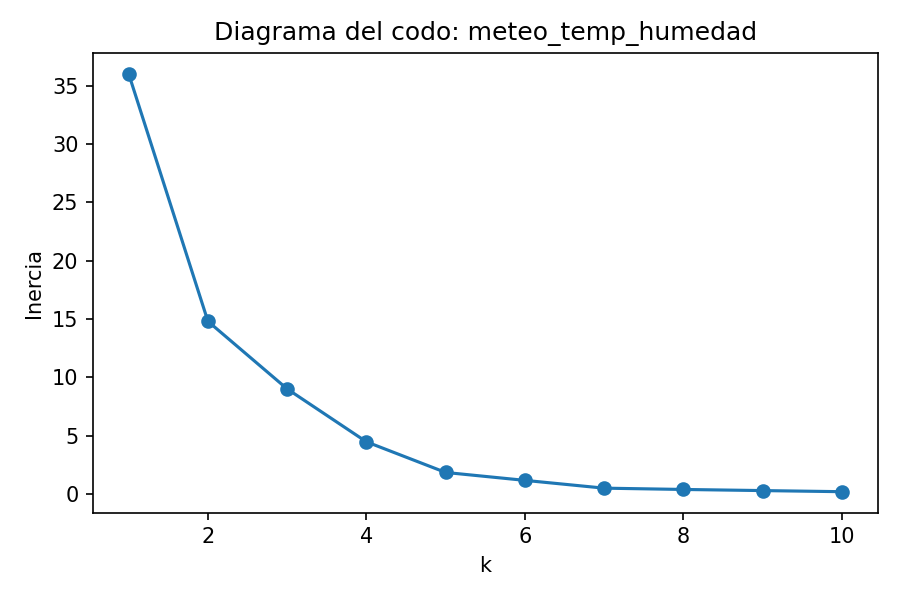

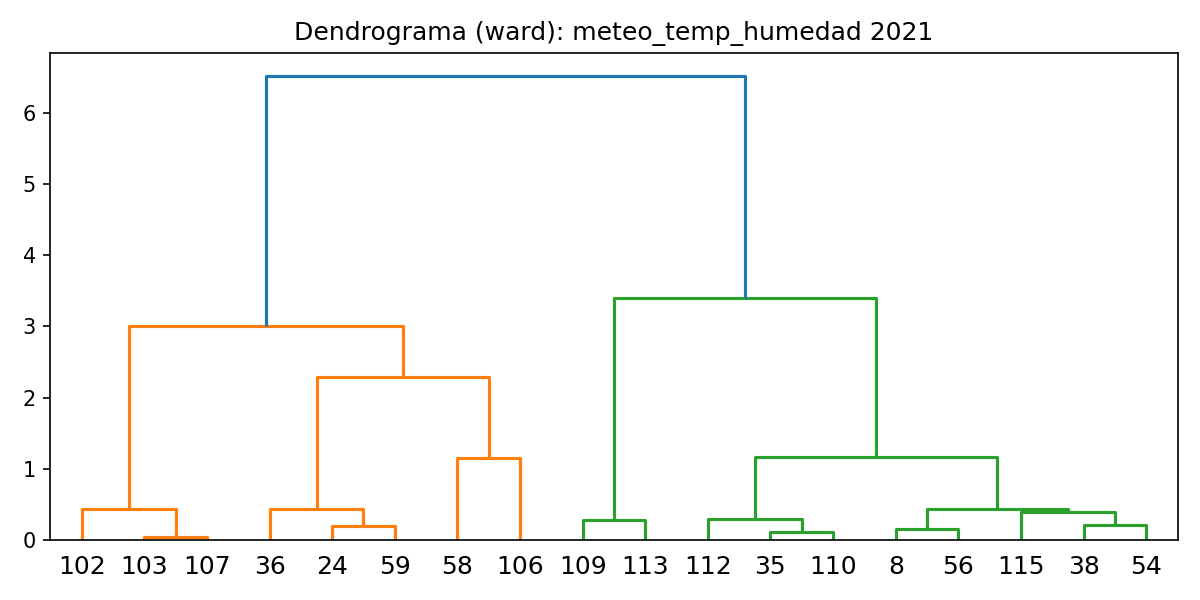

In [13]:
from IPython.display import Image, display
for f in ["arbolado_vs_temperatura.png", "codo_meteo_temp_humedad.png",
          "dendrograma_meteo_temp_humedad.png"]:
    display(Image(f"{base}/2021/{f}"))

In [14]:
!aws s3 sync {PROYECTO}/resultados/ s3://tfm-ucm-datos-publicos/resultados/

upload: resultados/README.md to s3://tfm-ucm-datos-publicos/resultados/README.md      
upload: resultados/isla_calor/propio/2019/arbolado_temperatura_distrito.csv to s3://tfm-ucm-datos-publicos/resultados/isla_calor/propio/2019/arbolado_temperatura_distrito.csv
upload: resultados/isla_calor/propio/2019/clusters_meteo_todas_magnitudes.csv to s3://tfm-ucm-datos-publicos/resultados/isla_calor/propio/2019/clusters_meteo_todas_magnitudes.csv
upload: resultados/isla_calor/propio/2019/codo_meteo_temp_humedad.png to s3://tfm-ucm-datos-publicos/resultados/isla_calor/propio/2019/codo_meteo_temp_humedad.png
upload: resultados/isla_calor/.ipynb_checkpoints/cobertura_temperatura-checkpoint.png to s3://tfm-ucm-datos-publicos/resultados/isla_calor/.ipynb_checkpoints/cobertura_temperatura-checkpoint.png
upload: resultados/ejecucion.log to s3://tfm-ucm-datos-publicos/resultados/ejecucion.log
upload: resultados/isla_calor/propio/2019/codo_contaminacion_no2_pm.png to s3://tfm-ucm-datos-publicos/resultado